# Stage 2: Meta-Learning Experiment Controller

This notebook is the interactive controller for Stage 2. It resolves Stage 2 experiments
from the central YAML configuration, optionally applies notebook-level overrides, previews
the resulting experiment list, optionally runs the selected experiments, and then loads
the saved registry for quick inspection.

Full comparative analysis belongs in `17.1_stage2_analysis_dashboard.ipynb`.


## Recommended Experiment Settings

The table below lists the recommended Stage 2 runs for the thesis, in order.
Each row corresponds to one run of this notebook with the listed `PRESET`
(and, where indicated, a small `PRESET_META_OVERRIDES` block). Every run
targets Logistics as the meta-test department; change `TARGET_DEPARTMENTS_OVERRIDE`
to fan out to other targets.

| # | Purpose | PRESET | Key overrides | Approx. runtime |
|---|---------|--------|---------------|-----------------|
| 1 | **Pipeline smoke test.** Confirm the code path runs end-to-end after the refactor. | `four_method_quick` | *(none)* | ~2 min |
| 2 | **No-adapt floor.** Pure Stage 1 MLP on every target episode across all three inits. | `zero_shot_only` | *(none)* | ~30 s |
| 3 | **Main Stage 2 benchmark.** zero_shot + ANIL + FOMAML + MAML + finetune at kpos=kneg=2, inner_steps ∈ {1,3,5}, meta_batch_size=4. | `five_method_benchmark` | *(none)* | ~25–40 min |
| 4 | **Inner-step ablation.** Same as run 3 but extended inner-step grid to trace the adaptation curve. | `five_method_benchmark` | `PRESET_META_OVERRIDES = {"inner_steps_grid": [1, 3, 5, 7]}` | ~35–55 min |
| 5 | **k-shot sweep (k = 1..5).** 5 methods × 5 support sizes × 1 inner-step setting. Drives the k-shot curve. | `k_shot_sweep` | *(none)* | ~40–70 min |
| 5b | *(optional)* **k-shot sweep, adaptive methods only.** Use if `zero_shot` is already cached from run 2/3. | `k_shot_sweep_adaptive` | *(none)* | ~30–55 min |
| 6 | **Initialization ablation.** Compare A_weak_only, C_hybrid, and random Stage 1 inits. | `five_method_benchmark` | `INIT_NAMES_OVERRIDE = ["A_weak_only", "C_hybrid", "random"]` | ~60–90 min |
| 7 | **Full thesis grid.** 4 methods × 3 support sizes × 2 inner_steps × 2 inits (48 experiments). Long. | `thesis_main` | *(none)* | ~2–4 h |

### How to run a k-shot few-shot experiment (k = 1, 2, 3, 4, 5)

**Option A — one-line preset (recommended):**

```python
PRESET = "k_shot_sweep"          # 5 methods × k ∈ {1..5}, inner_steps = 3
RUN_EXPERIMENTS = True
FORCE_RERUN = True
# Leave all *_OVERRIDE variables as None.
```

This expands to 25 experiments (5 methods × 5 support sizes) per init × target department. It writes one experiment folder per (method, k) pair under `models/stage_2/experiments/`, all with the same `inner_steps=3`, so `plot_support_size_curve` in the dashboard can draw one line per method as a function of k.

**Option B — inline override on top of another preset:**

```python
PRESET = "five_method_benchmark"
SUPPORT_GRID_OVERRIDE = [
    {"n_support_pos": 1, "n_support_neg": 1},
    {"n_support_pos": 2, "n_support_neg": 2},
    {"n_support_pos": 3, "n_support_neg": 3},
    {"n_support_pos": 4, "n_support_neg": 4},
    {"n_support_pos": 5, "n_support_neg": 5},
]
INNER_STEPS_OVERRIDE = [3]       # fix inner_steps so k is the only variable
```

**Option C — imbalanced k-shot (e.g. more negatives than positives):** use `imbalance_debug` as a starting point or pass an asymmetric `SUPPORT_GRID_OVERRIDE`:

```python
SUPPORT_GRID_OVERRIDE = [
    {"n_support_pos": 1, "n_support_neg": 5},
    {"n_support_pos": 2, "n_support_neg": 5},
    {"n_support_pos": 3, "n_support_neg": 5},
]
```

**Important caveats for large k:**

- Episodes need `n_support_pos + n_support_neg + 2` contracts to sample support + query. Departments that cannot supply that many are dropped by `filter_valid_departments`, so the **set of target episodes shrinks as k grows**. Check the per-k `n_target_episodes` in the Quick Summary Table before comparing scores across k.
- `meta_iterations` stays the same across k, so wall-clock scales roughly linearly in the number of grid cells (one outer loop per (method, k)).
- The zero-shot row is identical for every k (no support used), but emitting it at each k gives the dashboard a constant baseline line for the k-shot curve.

**How to run each table row**

1. Set `PRESET` in the control cell below.
2. Apply any overrides from the table (leave the rest as `None`).
3. Set `RUN_EXPERIMENTS = True` and `FORCE_RERUN = True` if you want to overwrite a previous run of that grid.
4. Execute all cells. After run #1 check that the *Post-run Sanity Check* section prints no `collapse_rate > 0.5` warnings.
5. Switch to `17.1_stage2_analysis_dashboard.ipynb` for plots, tables, and SHAP explanations.

**Minimum viable sequence** for the results chapter: runs 2, 3, and 5. Add run 4 for the inner-step curve, run 6 for the init-ablation. Run 7 is only needed for the full appendix grid.

### How to evaluate results

Every run writes to `models/stage_2/experiments/{experiment_id}/`:

- `metrics.csv` — gold-label scores per episode (AUROC, log-loss, NDCG@10, Precision@10, ECE). Aggregate in dashboard notebook tables D–I.
- `predictions.csv` — long-form per-contract probabilities. Feed into probability-distribution plots and SHAP.
- `history.csv` — outer-loop meta-loss trajectory (adaptive methods only). Feed into `plot_meta_training_curve`.
- `prediction_stats.csv` — label-free per-episode collapse diagnostic (mean, std, collapse flag). Feed into `plot_collapse_rate`.
- `stage2_result_summary.json` — one-row summary including the new `collapse_rate` and `pred_std_mean` fields.
- `resolved_config.yaml` — exact hyperparameters used.

**Evaluation checklist for each run**

1. **Sanity.** `collapse_rate` should be < 0.2 for every method. A method with collapse_rate > 0.5 is effectively predicting a constant — its AUROC is unreliable regardless of value.
2. **Floor comparison.** Every adaptive method must beat `zero_shot` on the same metric, support size, and target. If it doesn't, adaptation is hurting.
3. **Variance.** With `n_repeats` ≥ 10, look at `{metric}_std` columns in `experiment_summary.csv`. A mean difference smaller than one standard deviation is not evidence.
4. **k-shot curve.** Run 5 feeds `plot_support_size_curve`. Expect a flat line for `zero_shot` and a rising-then-plateauing curve for adaptive methods; the gap between them is the value of few-shot adaptation.
5. **Adaptation curve.** Use `plot_inner_step_curve` on the inner-step ablation (run 4). Expect a flat curve for `zero_shot` and an upward curve for adaptive methods until a plateau.
6. **Init ablation.** In run 6, `C_hybrid` (Snorkel + gold) should dominate `A_weak_only` which should dominate `random`. If not, that's a finding worth reporting.
7. **Explainability.** In notebook 17.1, compare `shap_pre` (zero-shot attribution) vs `shap_post` (adapted attribution) for the main run. Features whose importance changes most are the features Stage 2 actually uses for the target department.


In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
EXPERIMENTS_PATH = PROJECT_ROOT / "experiments"

for _p in [str(SRC_PATH), str(PROJECT_ROOT)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from master_thesis.stage2 import (
    load_stage2_config,
    resolve_experiment_grid,
    build_experiment_preview_df,
)
from master_thesis.plotting import set_thesis_style, plot_stage2_metric_comparison

set_thesis_style(palette="dtu", font_scale=1.05, grid=False)


{'zero_shot': '#DADADA',
 'zero-shot': '#DADADA',
 'pretrained': '#030F4F',
 'finetune': '#2F3EEA',
 'fine_tune': '#2F3EEA',
 'fine-tune': '#2F3EEA',
 'anil': '#1FD082',
 'fomaml': '#FC7634',
 'maml': '#990000',
 'xgboost': '#CC79A7',
 'elastic_net': '#56B4E9',
 'elastic net': '#56B4E9',
 'mean_predictor': '#999999',
 'mean predictor': '#999999'}

## Notebook-Level Experiment Controls

Edit the cell below to configure which experiments to run or preview.
All settings in this cell flow through the shared backend and produce the same
experiment IDs and artifact structure as the CLI runner.

---

### Recommended: Fair 4-method comparison (START HERE)

Run all four methods with **identical** settings so results are directly comparable:

```python
# Step 1 — sanity-check the pipeline (~2 min):
PRESET = "four_method_quick"
RUN_EXPERIMENTS = True

# Step 2 — full evaluation when the pipeline looks correct:
PRESET = "four_method_benchmark"
RUN_EXPERIMENTS = True
```

This produces exactly **4 experiments**, one per method (finetune / ANIL / FOMAML / MAML),
all using the same init (`A_weak_only`), support size (5+5), and inner steps (5).
After running, open `17.1_stage2_analysis_dashboard.ipynb` to compare results.

---

### Other common patterns

```python
# Full thesis grid — 48 experiments (4 methods × 3 support × 2 steps × 2 inits):
PRESET = "thesis_main"

# Force-rerun a previously completed experiment:
FORCE_RERUN = True

# Override specific grid dimensions without changing the preset:
PRESET = "four_method_benchmark"
SUPPORT_GRID_OVERRIDE = [{"n_support_pos": 10, "n_support_neg": 10}]
INNER_STEPS_OVERRIDE = [1, 3, 5]

# Use a different Stage 1 initialisation:
INIT_NAMES_OVERRIDE = ["C_hybrid"]
```


In [2]:
CONFIG_PATH = PROJECT_ROOT / "experiments" / "stage2_config.yaml"

# --- Preset selection ---
# Options:
#   "five_method_benchmark"  — zero_shot + 4 adaptive methods (full Stage 2 table) ← MAIN
#   "four_method_benchmark"  — 4 methods × same settings, full evaluation
#   "four_method_quick"      — minimal iterations (~2 min), for pipeline testing
#   "zero_shot_only"         — no-adapt Stage 1 floor across all three inits
#   "thesis_main"            — full grid: 4 methods × 3 support × 2 inner_steps × 2 inits (48 expts)
#   "quick_debug"            — 2 methods, minimal settings
#   "imbalance_debug"        — imbalanced support sizes
PRESET = "five_method_benchmark"

# --- Execution flags ---
# Set RUN_EXPERIMENTS = True to execute the resolved experiments.
RUN_EXPERIMENTS = True  
FORCE_RERUN = True

# --- Optional grid overrides (set to None to inherit from the preset) ---
# METHODS_OVERRIDE: list of method names, e.g. ["zero_shot", "anil", "finetune"]
METHODS_OVERRIDE = None
# SUPPORT_GRID_OVERRIDE: list of dicts, e.g. [{"n_support_pos": 5, "n_support_neg": 5}]
SUPPORT_GRID_OVERRIDE = None
# INNER_STEPS_OVERRIDE: list of int, e.g. [1, 3, 5]
INNER_STEPS_OVERRIDE = None
# INIT_NAMES_OVERRIDE: list of init names, e.g. ["A_weak_only", "C_hybrid"]
INIT_NAMES_OVERRIDE = None
# TARGET_DEPARTMENTS_OVERRIDE: list of dept names, e.g. ["Logistics"]
TARGET_DEPARTMENTS_OVERRIDE = None
# PRESET_META_OVERRIDES: dict of meta-config overrides, e.g. {"meta_iterations": 10, "n_repeats": 3}
PRESET_META_OVERRIDES = None


## Resolve Experiment Specification


In [3]:
full_config = load_stage2_config(CONFIG_PATH)

override_payload = {}
if METHODS_OVERRIDE is not None:
    override_payload["methods"] = METHODS_OVERRIDE
if SUPPORT_GRID_OVERRIDE is not None:
    override_payload["support_grid"] = SUPPORT_GRID_OVERRIDE
if INNER_STEPS_OVERRIDE is not None:
    override_payload["inner_steps_grid"] = INNER_STEPS_OVERRIDE
if INIT_NAMES_OVERRIDE is not None:
    override_payload["init_names"] = INIT_NAMES_OVERRIDE
if TARGET_DEPARTMENTS_OVERRIDE is not None:
    override_payload["target_departments"] = TARGET_DEPARTMENTS_OVERRIDE
if PRESET_META_OVERRIDES is not None:
    override_payload.update(PRESET_META_OVERRIDES)

experiment_list = resolve_experiment_grid(
    full_config=full_config,
    preset_name=PRESET,
    overrides=override_payload,
)

preview_df = build_experiment_preview_df(experiment_list)
exp_ids = [exp_id for exp_id, _ in experiment_list]

print("Selected preset:", PRESET)
print("Run experiments:", RUN_EXPERIMENTS)
print("Force rerun:", FORCE_RERUN)
print("Resolved experiments:", len(preview_df))
display(preview_df)


Selected preset: five_method_benchmark
Run experiments: True
Force rerun: True
Resolved experiments: 15


,experiment_id,method,n_support_pos,n_support_neg,inner_steps,init_name,target_department,data_filename
0,stage2__init-A_weak_only__method-zero_shot__kp...,zero_shot,2,2,1,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv
1,stage2__init-A_weak_only__method-zero_shot__kp...,zero_shot,2,2,3,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv
2,stage2__init-A_weak_only__method-zero_shot__kp...,zero_shot,2,2,5,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv
3,stage2__init-A_weak_only__method-finetune__kpo...,finetune,2,2,1,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv
4,stage2__init-A_weak_only__method-finetune__kpo...,finetune,2,2,3,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv
5,stage2__init-A_weak_only__method-finetune__kpo...,finetune,2,2,5,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv
6,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,2,2,1,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv
7,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,2,2,3,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv
8,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,2,2,5,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv
9,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,2,2,1,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv


## Diagnostics


In [4]:
if len(experiment_list) == 0:
    raise ValueError("Resolved experiment list is empty.")

first_experiment_id, first_config = experiment_list[0]
data_filename = first_config["data"]["data_filename"]
data_path = PROJECT_ROOT / "Data" / "processed" / data_filename

print("First experiment ID:", first_experiment_id)
print("Stage 2 data file:", data_path)
print("Target department:", first_config["task_config"]["target_department"])
print("Stage 1 initialization:", first_config["stage1_init"]["init_name"])

if not data_path.exists():
    raise FileNotFoundError(f"Stage 2 data file not found: {data_path}")

df_stage2 = pd.read_csv(data_path, low_memory=False)
print("Dataset shape:", df_stage2.shape)
print("Has gold_y:", "gold_y" in df_stage2.columns)
print("Has renegotiation_prob:", "renegotiation_prob" in df_stage2.columns)


First experiment ID: stage2__init-A_weak_only__method-zero_shot__kpos-2__kneg-2__steps-1__target-Logistics
Stage 2 data file: /Users/Thomas/Desktop/Master Thesis/Data/processed/contract_with_features_labeled_with_gold.csv
Target department: Logistics
Stage 1 initialization: A_weak_only
Dataset shape: (9201, 168)
Has gold_y: True
Has renegotiation_prob: True


## Optional Execution

Set `RUN_EXPERIMENTS = True` in the controls cell above to run the resolved experiments.
Results are saved to `models/stage_2/experiments/<experiment_id>/` and indexed in
`models/stage_2/experiments/experiment_summary.csv`.


In [5]:
if RUN_EXPERIMENTS:
    import importlib.util
    _spec = importlib.util.spec_from_file_location(
        "run_stage2", EXPERIMENTS_PATH / "run_stage2.py"
    )
    _run_stage2_mod = importlib.util.module_from_spec(_spec)
    _spec.loader.exec_module(_run_stage2_mod)
    run_experiments = _run_stage2_mod.run_experiments

    results = run_experiments(
        experiment_list=experiment_list,
        skip_if_exists=not FORCE_RERUN,
        force_rerun=FORCE_RERUN,
        verbose=True,
    )
    print(f"Completed {len(results)} experiment rows.")
else:
    print("Execution skipped. Set RUN_EXPERIMENTS = True to run the resolved experiments.")


Running experiment: stage2__init-A_weak_only__method-zero_shot__kpos-2__kneg-2__steps-1__target-Logistics
Stage 2 task table created
Rows: 700
Unique contracts: 126
Departments: 14
Positive labels: 387
Negative labels: 313
Department task summary created
Departments: 14
Total labeled rows: 700
Total positive rows: 387
Total negative rows: 313
Total labeled contracts: 126
Total positive contracts: 68
Total negative contracts: 58
Department task summary created
Departments: 14
Total labeled rows: 700
Total positive rows: 387
Total negative rows: 313
Total labeled contracts: 126
Total positive contracts: 68
Total negative contracts: 58
Department validity filtering completed
Valid departments: 12
Invalid departments: 2
Running experiment: stage2__init-A_weak_only__method-zero_shot__kpos-2__kneg-2__steps-3__target-Logistics
Stage 2 task table created
Rows: 700
Unique contracts: 126
Departments: 14
Positive labels: 387
Negative labels: 313
Department task summary created
Departments: 14
Tot

## Post-run Sanity Check

Verifies that every successful experiment in this batch produced a
non-empty `metrics.csv` and, where applicable, a non-collapsed prediction
distribution. This is a **label-free** check — it does not consult gold
labels, only predicted probability statistics.

In [6]:
from pathlib import Path
import pandas as pd

EXPERIMENT_ROOT = PROJECT_ROOT / "models" / "stage_2" / "experiments"
sanity_rows = []
for exp_id in exp_ids:
    exp_dir = EXPERIMENT_ROOT / exp_id
    metrics_path = exp_dir / "metrics.csv"
    stats_path = exp_dir / "prediction_stats.csv"
    row = {"experiment_id": exp_id,
           "metrics_exists": metrics_path.exists(),
           "stats_exists": stats_path.exists()}
    if stats_path.exists():
        try:
            s = pd.read_csv(stats_path)
            row["n_episodes"] = len(s)
            row["collapse_rate"] = float(s["collapsed"].mean()) if "collapsed" in s.columns else None
            row["pred_std_mean"] = float(s["pred_std"].mean()) if "pred_std" in s.columns else None
        except Exception as e:
            row["stats_read_error"] = str(e)
    sanity_rows.append(row)

sanity_df = pd.DataFrame(sanity_rows)
if sanity_df.empty:
    print("No experiments to check.")
else:
    high_collapse = sanity_df[sanity_df.get("collapse_rate", 0) > 0.5]
    if not high_collapse.empty:
        print(f"{len(high_collapse)} experiment(s) show >50% collapsed episodes (inspect diagnostic dashboard).")
    display(sanity_df.sort_values("collapse_rate", ascending=False, na_position="last"))

5 experiment(s) show >50% collapsed episodes (inspect diagnostic dashboard).


,experiment_id,metrics_exists,stats_exists,n_episodes,collapse_rate,pred_std_mean
9,stage2__init-A_weak_only__method-fomaml__kpos-...,True,True,20.0,1.00,0.000208
12,stage2__init-A_weak_only__method-maml__kpos-2_...,True,True,20.0,1.00,0.000093
3,stage2__init-A_weak_only__method-finetune__kpo...,True,True,20.0,0.90,0.010714
4,stage2__init-A_weak_only__method-finetune__kpo...,True,True,20.0,0.90,0.010714
5,stage2__init-A_weak_only__method-finetune__kpo...,True,True,20.0,0.90,0.010714
6,stage2__init-A_weak_only__method-anil__kpos-2_...,True,True,20.0,0.40,0.061477
8,stage2__init-A_weak_only__method-anil__kpos-2_...,True,True,20.0,0.35,0.109630
7,stage2__init-A_weak_only__method-anil__kpos-2_...,True,True,20.0,0.20,0.114426
0,stage2__init-A_weak_only__method-zero_shot__kp...,True,True,20.0,0.00,0.311018
1,stage2__init-A_weak_only__method-zero_shot__kp...,True,True,20.0,0.00,0.311018


## Backfill Legacy Results

This cell detects any Stage 2 experiment results that were saved in the legacy
directory structure (`models/stage_2/{init_name}/{method}/`) and migrates them
into the grid-based `experiments/` registry used by this notebook and notebook 17.1.

Run this cell once after any run that used the old-style pipeline.
It is safe to run multiple times — already-registered experiments are skipped.


In [7]:
from master_thesis.stage2 import backfill_legacy_stage2_results

backfill_summary = backfill_legacy_stage2_results(verbose=True)

if not backfill_summary.empty:
    print(f"Registry now contains {len(backfill_summary)} experiment(s).")
    _method_counts = backfill_summary['method'].value_counts() if 'method' in backfill_summary.columns else {}
    print('Methods in registry:', _method_counts.to_dict())


Already registered, skipping: stage2__init-A_weak_only__method-anil__kpos-2__kneg-2__steps-5__target-Logistics
Already registered, skipping: stage2__init-A_weak_only__method-maml__kpos-2__kneg-2__steps-5__target-Logistics
Already registered, skipping: stage2__init-A_weak_only__method-finetune__kpos-2__kneg-2__steps-5__target-Logistics
Already registered, skipping: stage2__init-A_weak_only__method-fomaml__kpos-2__kneg-2__steps-5__target-Logistics
No new legacy experiments found to backfill.
Registry now contains 15 experiment(s).
Methods in registry: {'anil': 3, 'finetune': 3, 'fomaml': 3, 'maml': 3, 'zero_shot': 3}


## Load Experiment Registry


In [8]:
EXPERIMENT_ROOT = PROJECT_ROOT / "models" / "stage_2" / "experiments"
SUMMARY_PATH = EXPERIMENT_ROOT / "experiment_summary.csv"

if SUMMARY_PATH.exists():
    experiment_summary = pd.read_csv(SUMMARY_PATH)
    print("Loaded experiment summary:", SUMMARY_PATH)
    print("Rows:", len(experiment_summary))
    display(experiment_summary.head(20))
else:
    print("No experiment summary file found yet at:", SUMMARY_PATH)
    experiment_summary = pd.DataFrame()


Loaded experiment summary: /Users/Thomas/Desktop/Master Thesis/models/stage_2/experiments/experiment_summary.csv
Rows: 15


,experiment_id,method,init_name,target_department,n_support_pos,n_support_neg,inner_steps,status,gold_auroc_mean,gold_auroc_std,...,n_metric_rows,n_predictions,n_episodes_diagnosed,collapse_rate,pred_mean_mean,pred_std_mean,frac_near_zero_mean,frac_near_one_mean,was_skipped,error
0,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,Logistics,2,2,1,success,0.419169,0.189286,...,20.0,821.0,20.0,0.40,0.643810,0.061477,0.203041,0.291167,False,NaN
1,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,Logistics,2,2,3,success,0.518109,0.194236,...,20.0,821.0,20.0,0.20,0.749719,0.114426,0.002273,0.311122,False,NaN
2,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,Logistics,2,2,5,success,0.631584,0.216482,...,20.0,821.0,20.0,0.35,0.431226,0.109630,0.391103,0.276584,False,NaN
3,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,Logistics,2,2,1,success,0.481247,0.046757,...,20.0,821.0,20.0,0.90,0.346587,0.010714,0.642000,0.326250,False,NaN
4,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,Logistics,2,2,3,success,0.481247,0.046757,...,20.0,821.0,20.0,0.90,0.346587,0.010714,0.642000,0.326250,False,NaN
5,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,Logistics,2,2,5,success,0.481247,0.046757,...,20.0,821.0,20.0,0.90,0.346587,0.010714,0.642000,0.326250,False,NaN
6,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,Logistics,2,2,1,success,0.513183,0.014697,...,20.0,821.0,20.0,1.00,0.382385,0.000208,0.350000,0.000000,False,NaN
7,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,Logistics,2,2,3,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Input contains NaN.
8,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,Logistics,2,2,5,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Input contains NaN.
9,stage2__init-A_weak_only__method-maml__kpos-2_...,maml,A_weak_only,Logistics,2,2,1,success,0.507920,0.018085,...,20.0,821.0,20.0,1.00,0.324588,0.000093,0.000000,0.000000,False,NaN


## Quick Comparison Preview


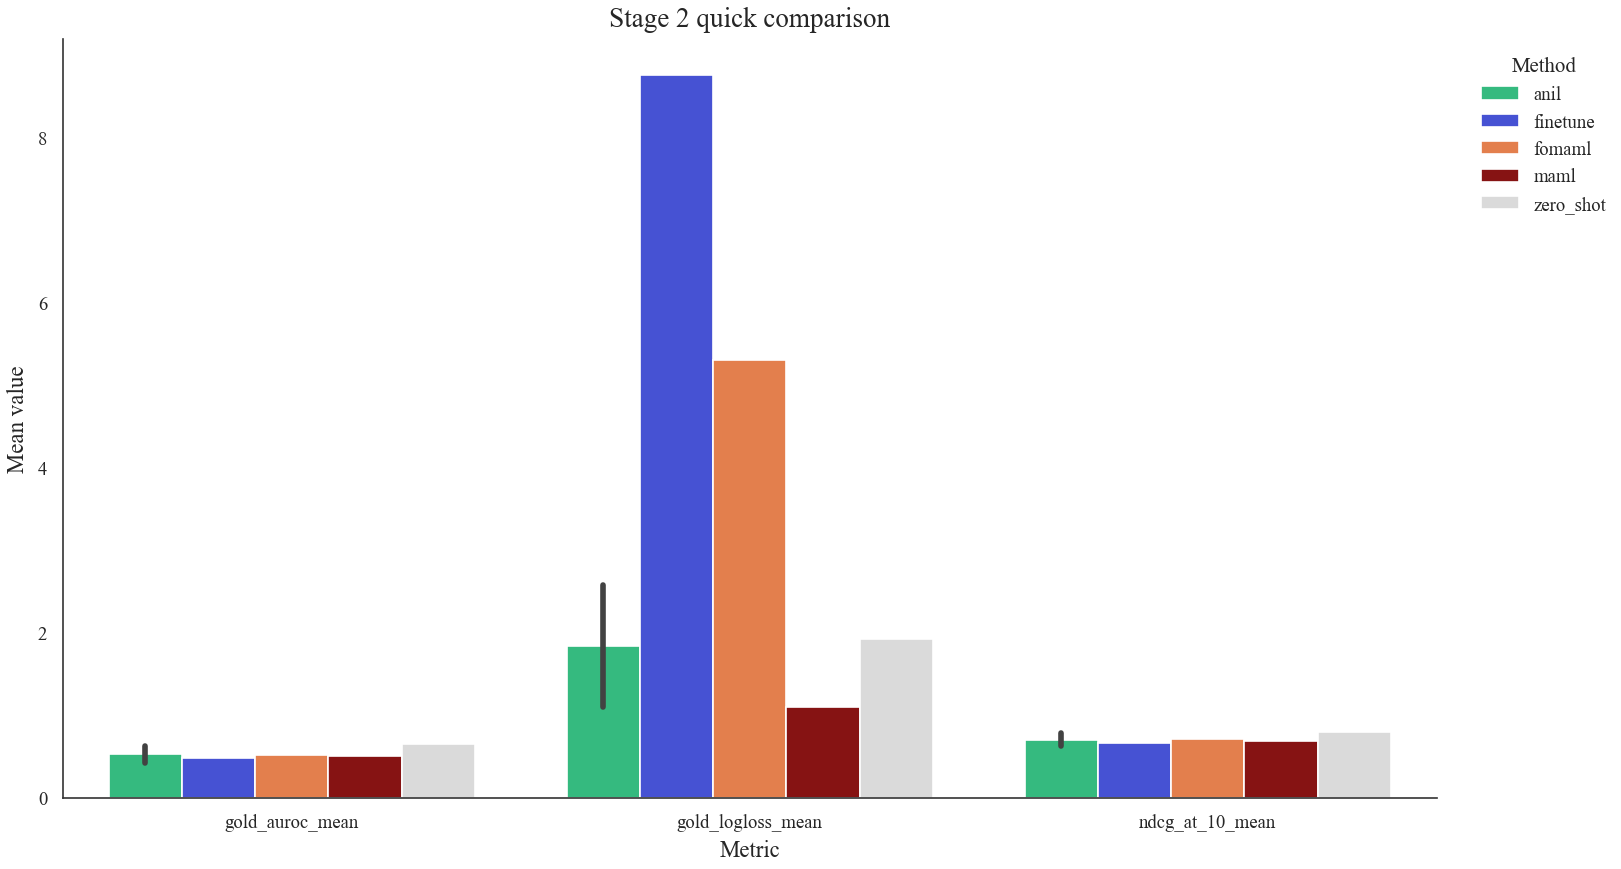

In [9]:
if not experiment_summary.empty:
    quick_df = experiment_summary.copy()
    if "target_department" in quick_df.columns:
        quick_df = quick_df[
            quick_df["target_department"] == first_config["task_config"]["target_department"]
        ].copy()

    metric_columns = [
        c for c in ["gold_auroc_mean", "gold_logloss_mean", "ndcg_at_10_mean"] if c in quick_df.columns
    ]
    if metric_columns and "method" in quick_df.columns:
        fig, ax = plot_stage2_metric_comparison(
            quick_df,
            metrics=metric_columns,
            group_col="method",
            title="Stage 2 quick comparison",
        )
    else:
        display(quick_df.head(20))
else:
    print("No saved experiment results are available yet.")


## Quick Summary Table

Compact result table for fast inspection. Full thesis-ready tables are in `17.1_stage2_analysis_dashboard.ipynb`.


In [10]:
if not experiment_summary.empty:
    _metric_cols = [c for c in experiment_summary.columns if c.endswith("_mean")]
    _key_cols = ["experiment_id", "method", "init_name", "n_support_pos", "n_support_neg",
                  "inner_steps", "target_department", "status", "n_metric_rows"]
    _display_cols = [c for c in _key_cols if c in experiment_summary.columns] + _metric_cols
    _display_cols = list(dict.fromkeys(_display_cols))  # deduplicate preserving order

    quick_summary = experiment_summary[_display_cols].copy()
    _sort_by = [c for c in ["method", "init_name", "n_support_pos", "inner_steps"] if c in quick_summary.columns]
    if _sort_by:
        quick_summary = quick_summary.sort_values(_sort_by).reset_index(drop=True)
    display(quick_summary)
else:
    print("Run experiments first to populate the summary.")


,experiment_id,method,init_name,n_support_pos,n_support_neg,inner_steps,target_department,status,n_metric_rows,gold_auroc_mean,...,precision_at_10_mean,recall_at_10_mean,ndcg_at_10_mean,precision_at_20_mean,recall_at_20_mean,ndcg_at_20_mean,pred_mean_mean,pred_std_mean,frac_near_zero_mean,frac_near_one_mean
0,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,2,2,1,Logistics,success,20.0,0.419169,...,0.610,0.220263,0.616339,0.6100,0.442012,0.614745,0.643810,0.061477,0.203041,0.291167
1,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,2,2,3,Logistics,success,20.0,0.518109,...,0.715,0.254389,0.723686,0.6825,0.489149,0.696501,0.749719,0.114426,0.002273,0.311122
2,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,2,2,5,Logistics,success,20.0,0.631584,...,0.765,0.268707,0.768404,0.7425,0.527200,0.749970,0.431226,0.109630,0.391103,0.276584
3,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,2,2,1,Logistics,success,20.0,0.481247,...,0.635,0.223603,0.660763,0.7375,0.524005,0.669617,0.346587,0.010714,0.642000,0.326250
4,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,2,2,3,Logistics,success,20.0,0.481247,...,0.635,0.223603,0.660763,0.7375,0.524005,0.669617,0.346587,0.010714,0.642000,0.326250
5,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,2,2,5,Logistics,success,20.0,0.481247,...,0.635,0.223603,0.660763,0.7375,0.524005,0.669617,0.346587,0.010714,0.642000,0.326250
6,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,2,2,1,Logistics,success,20.0,0.513183,...,0.705,0.247339,0.704331,0.7825,0.553836,0.704331,0.382385,0.000208,0.350000,0.000000
7,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,2,2,3,Logistics,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,2,2,5,Logistics,failed,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,stage2__init-A_weak_only__method-maml__kpos-2_...,maml,A_weak_only,2,2,1,Logistics,success,20.0,0.507920,...,0.695,0.243339,0.691430,0.7800,0.551836,0.696005,0.324588,0.000093,0.000000,0.000000


## Artifact Verification

Check which expected artifacts are present for each resolved experiment.


In [11]:
artifact_names = ["resolved_config.yaml", "metrics.csv", "predictions.csv",
                   "history.csv", "stage2_result_summary.json"]

artifact_rows = []
for exp_id, _ in experiment_list:
    exp_dir = EXPERIMENT_ROOT / exp_id
    row = {"experiment_id": exp_id}
    for name in artifact_names:
        row[name] = (exp_dir / name).exists()
    artifact_rows.append(row)

artifact_df = pd.DataFrame(artifact_rows)
display(artifact_df)


,experiment_id,resolved_config.yaml,metrics.csv,predictions.csv,history.csv,stage2_result_summary.json
0,stage2__init-A_weak_only__method-zero_shot__kp...,True,True,True,False,True
1,stage2__init-A_weak_only__method-zero_shot__kp...,True,True,True,False,True
2,stage2__init-A_weak_only__method-zero_shot__kp...,True,True,True,False,True
3,stage2__init-A_weak_only__method-finetune__kpo...,True,True,True,False,True
4,stage2__init-A_weak_only__method-finetune__kpo...,True,True,True,True,True
5,stage2__init-A_weak_only__method-finetune__kpo...,True,True,True,True,True
6,stage2__init-A_weak_only__method-anil__kpos-2_...,True,True,True,True,True
7,stage2__init-A_weak_only__method-anil__kpos-2_...,True,True,True,True,True
8,stage2__init-A_weak_only__method-anil__kpos-2_...,True,True,True,True,True
9,stage2__init-A_weak_only__method-fomaml__kpos-...,True,True,True,True,True
